# Chapter 13 - Backtesting on Synthetic Data

## Preparation

In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from scipy.stats import norm, moment
from random import gauss
from itertools import product

from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC

from utils.sampling_bars import dollar_bar
from utils.synthetic import fit_ou_process, explain_and_plot_ou_params, simulate_ou_process


%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

In [3]:
dollar_bars.head()

,price,bid,ask,vol,dollar_vol,trade_count,price_high,price_low
date,,,,,,,,
2009-09-28 09:31:50,50.75,50.73,50.76,300.0,15225.00,1.0,50.75,50.75
2009-09-28 09:33:02,50.81,50.80,50.81,800.0,40648.00,2.0,50.81,50.81
2009-09-28 09:34:04,50.82,50.80,50.82,100.0,5082.00,1.0,50.82,50.82
2009-09-28 09:38:28,50.81,50.79,50.81,195.0,9907.95,1.0,50.81,50.81
2009-09-28 09:42:17,50.85,50.83,50.85,200.0,10170.00,2.0,50.85,50.85


## 1. Suppose you are an execution trader. A client calls you with an order to cover a short position she entered at a price of 100. She gives you two exit conditions: profit-taking at 90 and stop-loss at 105.

### a. Assuming the client believes the price follows an O-U process, are these  levels reasonable? For what parameters?

Yes it's reasonable, as the stop loss is large enough to wait for the price to rebound even in a temporary loss. We could expect the set future price $E_0[P_{i,T_i}]$ to be 105, $\tau$ to be 10, and the $\sigma$ to be 1.

### b. Can you think of an alternative stochastic process under which these levels make sense?

**Geometric Brownian Motion (GBM) with a negative drift.**

Under a GBM $dP = \mu P\,dt + \sigma P\,dW_t$ with $\mu < 0$, the price is expected to trend downward from 100 toward 90. This directional view justifies the *asymmetric* barriers:
- Profit-taking at 90 (−10): placed in the direction of the expected trend, wide enough to let the drift play out.
- Stop-loss at 105 (+5): tighter, cutting the position if the price moves against the trend beyond a tolerable amount.

A pure Brownian motion (zero drift) would *not* justify asymmetric barriers with no drift. The optimal stopping rule is symmetric, so profit-taking and stop-loss distances should be equal. The asymmetry only makes sense under a **directional process** (drift or mean-reversion toward a target below 100).

## 2. Fit the time series of dollar bars of E-mini S&P 500 futures to an O-U  process. Given those parameters:

=== O-U Process Parameters ===
  Long-run mean    θ  : 234.2771
  Mean-rev. speed  κ  : 0.000001  (per bar)
  Diffusion coeff  σ  : 0.0849
  Half-life            : 636244.9  bars
  β (AR coeff)         : -0.000001  (negative ⟹ mean-reverting)
  R²                   : 0.0000
  p-value (β)          : 4.9982e-01


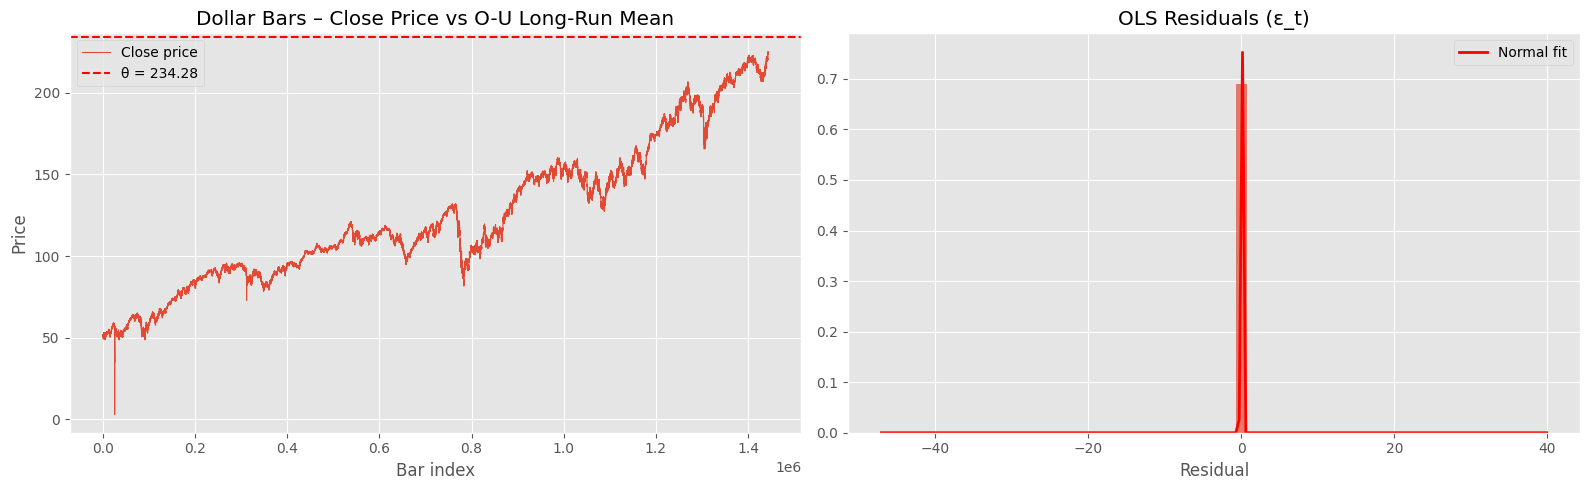

In [ ]:
# Fit to the closing prices of the dollar bars
ou_params = fit_ou_process(dollar_bars["price"])

explain_and_plot_ou_params(ou_params, dollar_bars)

### a. Produce a heat-map of Sharpe ratios for various profit-taking and stoploss levels.

In [6]:
ou_params["phi"] = 1 + ou_params["beta"]
ou_params["forecast"] = -ou_params["alpha"] / ou_params["beta"]

profit_targets = np.linspace(0.5, 10, 10)
stop_loss_multipliers = np.linspace(0.5, 10, 10)
results = simulate_ou_process(ou_params, r_pt=profit_targets, r_slm=stop_loss_multipliers)

results

0.5 0.5 0.012336456528859702 0.5509482555418219 0.022391316071465904
0.5 1.5555555555555556 0.3525811645294597 0.6223814674033045 0.5665033150818201
0.5 2.611111111111111 0.5380722355338107 0.1947966161460024 2.7622257828673935
0.5 3.666666666666667 0.5492425454496388 0.04631368248125412 11.859185364324023
0.5 4.722222222222222 0.549289145859133 0.042185938907680645 13.020668973640548
0.5 5.777777777777778 0.5494893713741589 0.0424048304069873 12.958178728704835
0.5 6.833333333333334 0.549292271363697 0.042260043949985185 12.997910556216768
0.5 7.888888888888889 0.5492555317502841 0.04245933604818671 12.936036755896017
0.5 8.944444444444445 0.5495342308830509 0.042679145663581455 12.875942625814414
0.5 10.0 0.5495187867269905 0.04269982302323165 12.869345768201764
1.5555555555555556 0.5 -0.3132054785246136 0.6744789982657271 -0.46436653969945973
1.5555555555555556 1.5555555555555556 0.06087658065612998 1.604396677322557 0.03794359681529745
1.5555555555555556 2.611111111111111 1.4979345

[(np.float64(0.5),
  np.float64(0.5),
  np.float64(0.012336456528859702),
  np.float64(0.5509482555418219),
  np.float64(0.022391316071465904)),
 (np.float64(0.5),
  np.float64(1.5555555555555556),
  np.float64(0.3525811645294597),
  np.float64(0.6223814674033045),
  np.float64(0.5665033150818201)),
 (np.float64(0.5),
  np.float64(2.611111111111111),
  np.float64(0.5380722355338107),
  np.float64(0.1947966161460024),
  np.float64(2.7622257828673935)),
 (np.float64(0.5),
  np.float64(3.666666666666667),
  np.float64(0.5492425454496388),
  np.float64(0.04631368248125412),
  np.float64(11.859185364324023)),
 (np.float64(0.5),
  np.float64(4.722222222222222),
  np.float64(0.549289145859133),
  np.float64(0.042185938907680645),
  np.float64(13.020668973640548)),
 (np.float64(0.5),
  np.float64(5.777777777777778),
  np.float64(0.5494893713741589),
  np.float64(0.0424048304069873),
  np.float64(12.958178728704835)),
 (np.float64(0.5),
  np.float64(6.833333333333334),
  np.float64(0.5492922713

In [7]:
def plot_heat_map(results):
    heatdf = pd.DataFrame(results, columns=["profit_taking", "stop_loss", "mean", "std", "sharpe"])

    # Pivot: rows = stop_loss, cols = profit_taking, values = sharpe ratio
    heatmap_data = heatdf.pivot(index="stop_loss", columns="profit_taking", values="sharpe")
    # Sort stop-loss descending so larger values appear at the top
    heatmap_data = heatmap_data.sort_index(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap="RdYlGn",
        annot=True,
        fmt=".2f",
        linewidths=0.4,
        cbar_kws={"label": "Sharpe Ratio"},
    )
    ax.set_title("Sharpe Ratio Heatmap — O-U Simulation", fontsize=14)
    ax.set_xlabel("Profit Taking (r_pt)", fontsize=12)
    ax.set_ylabel("Stop Loss (r_slm)", fontsize=12)
    ax.set_xticklabels([f"{float(t.get_text()):.2f}" for t in ax.get_xticklabels()], rotation=45, ha="right")
    ax.set_yticklabels([f"{float(t.get_text()):.2f}" for t in ax.get_yticklabels()], rotation=0)
    plt.tight_layout()
    plt.show()

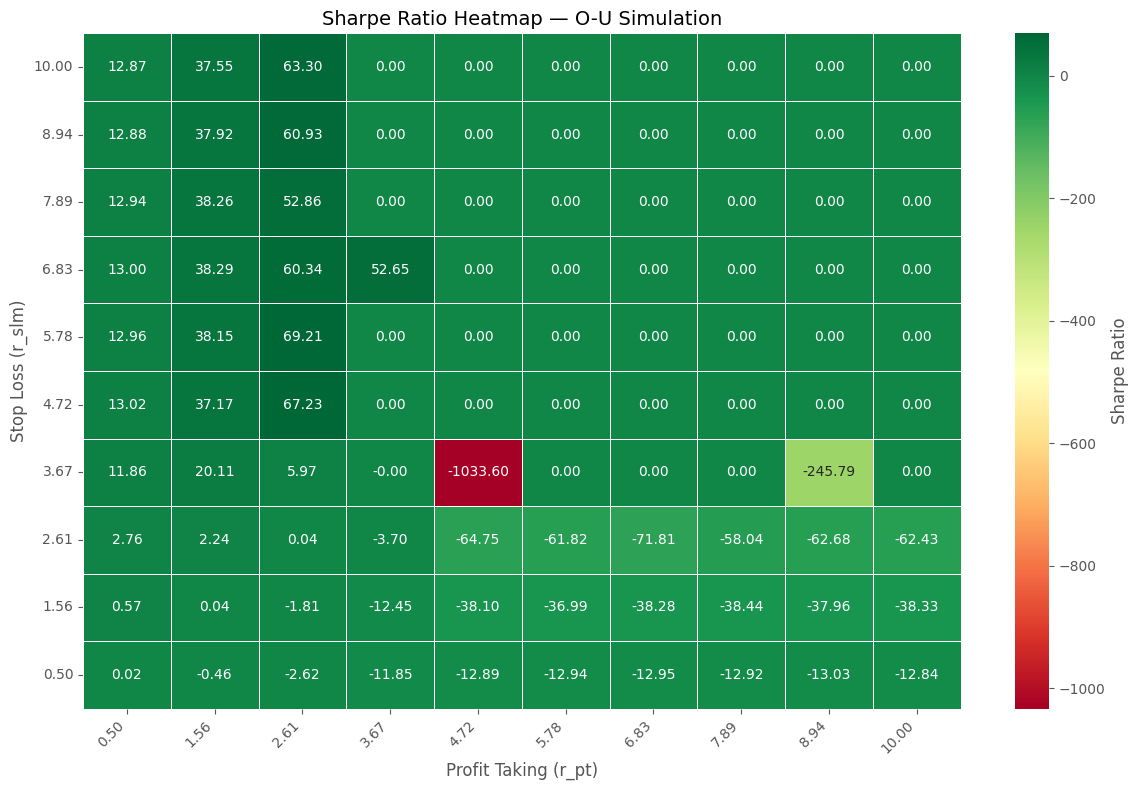

In [10]:
plot_heat_map(results)

## b. What is the OTR?

In [15]:
sharpe_ratios = [res[-1] for res in results]
max_sr_idx = np.argmax(sharpe_ratios)
max_sr_values = results[max_sr_idx]
print(f"The OTR is")
print(f"Profit Target: {max_sr_values[0]:.2f}")
print(f"Stop Loss Multiplier: {max_sr_values[1]:.2f}")
print(f"Sharpe Ratio: {max_sr_values[-1]:.2f}")


The OTR is
Profit Target: 2.61
Stop Loss Multiplier: 5.78
Sharpe Ratio: 69.21


## 3. Repeat exercise 2, this time on a time series of dollar bars of

### a. 10-year U.S. Treasure Notes futures

### b. WTI Crude Oil futures

Since we don't have the data, we will do it on the Euro Stoxx 50 Index

In [16]:
eurostoxx = pd.read_csv('../data/raw/eurostoxx.csv')

# rename columns to universal format
eurostoxx.rename(columns = {'Date': 'date', 'Price': 'close', 'Open': 'open', 'Vol.': 'vol'}, inplace=True)

eurostoxx['date'] = pd.to_datetime(eurostoxx.date)

# convert price data from strings to float (investing.com uses specific decimal sep format)
eurostoxx.close = eurostoxx.close.apply(lambda x: x.replace(',', '')).astype(float)
eurostoxx.open = eurostoxx.open.apply(lambda x: x.replace(',', '')).astype(float)

def extract_mult(s) -> int:
    """Extract numeric value from string with 'K', 'M', 'B', or 'T' and return as integer."""
    if isinstance(s, (int, float)):
        return int(s)
    if isinstance(s, str):
        s = s.strip()
        mult = 1
        if s.endswith("K"):
            mult = 1e3
            s = s[:-1]
        elif s.endswith("M"):
            mult = 1e6
            s = s[:-1]
        elif s.endswith("B"):
            mult = 1e9
            s = s[:-1]
        elif s.endswith("T"):
            mult = 1e12
            s = s[:-1]
        try:
            return int(float(s.replace(",", "")) * mult)
        except ValueError:
            return 0
    return 0

eurostoxx.vol = eurostoxx.vol.apply(extract_mult)
eurostoxx.set_index('date', inplace=True)
eurostoxx.sort_index(inplace=True)

In [17]:
DICTIO = {'Instrument':'date', 'Close':'close', 'Open':'open', 'Returns':'returns', 'rPrices':'rPrices', 'Volume':'vol'}

def getRolledSeries(series, dictio=DICTIO):
    gaps = rollGaps(series, dictio)
    for field in [dictio.get('Close', None), dictio.get('VWAP', None)]:
        if field is None:
            continue
        if field in series.columns:
            series[field] -= gaps
        else:
            print(f"[WARNING] Field {field} not found in series")
    return series


def rollGaps(series, dictio, matchEnd=True):
    # Compute gaps at each roll, between previous close and next open
    target_series = series.copy(deep=True)
    rollDates = target_series.index
    gaps = target_series[dictio['Close']] * 0
    iloc = list(target_series.index)
    iloc = [iloc.index(i) - 1 for i in rollDates] # index of days prior to roll
    gaps.loc[rollDates[1:]] = target_series[dictio['Open']].loc[rollDates[1:]] - target_series[dictio['Close']].iloc[iloc[1:]].values
    gaps = gaps.cumsum()
    if matchEnd:
        gaps -= gaps.iloc[-1]
    return gaps

def non_negative_series(series, dictio=DICTIO):
    target_series = series.copy(deep=True)
    target_series[dictio['Returns']] = target_series[dictio['Close']].diff() / target_series[dictio['Close']].shift(1)
    target_series[dictio['rPrices']] = (1 + target_series[dictio['Returns']]).cumprod()
    return target_series

In [18]:
eurostoxx_bars = non_negative_series(eurostoxx)

eurostoxx_bars.head()

,close,open,High,Low,vol,Change %,returns,rPrices
date,,,,,,,,
2016-03-08,3002.0,3001.0,"3,026","2,966",1750000,-0.53%,NaN,NaN
2016-03-09,3018.0,3009.0,"3,048","3,000",1600000,0.53%,0.005330,1.005330
2016-03-10,2979.0,3019.0,"3,130","2,935",3340000,-1.29%,-0.012922,0.992338
2016-03-11,3072.0,3016.0,"3,088","3,016",2460000,3.12%,0.031219,1.023318
2016-03-14,3090.0,3085.0,"3,117","3,078",2310000,0.59%,0.005859,1.029314


=== O-U Process Parameters ===
  Long-run mean    θ  : 3337.7101
  Mean-rev. speed  κ  : 0.009883  (per bar)
  Diffusion coeff  σ  : 30.3241
  Half-life            : 70.1  bars
  β (AR coeff)         : -0.009883  (negative ⟹ mean-reverting)
  R²                   : 0.0055
  p-value (β)          : 3.7791e-02


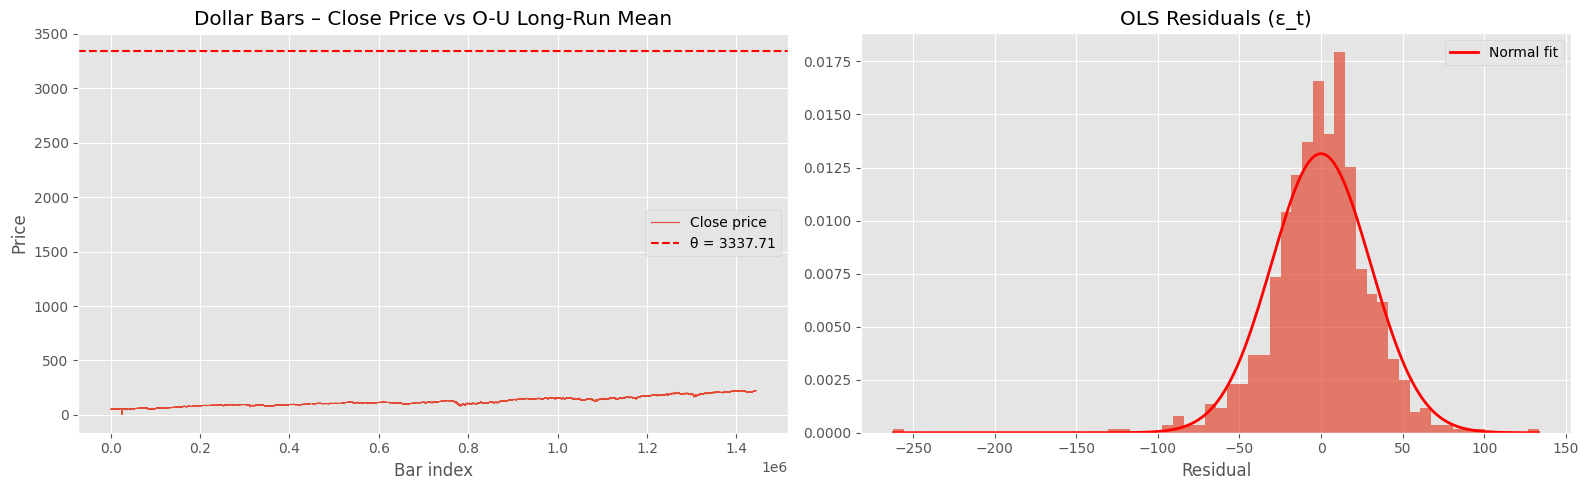

In [ ]:
eurostoxx_ou_params = fit_ou_process(eurostoxx_bars["close"])

explain_and_plot_ou_params(eurostoxx_ou_params, eurostoxx_bars)

In [20]:
eurostoxx_ou_params["phi"] = 1 + eurostoxx_ou_params["beta"]
eurostoxx_ou_params["forecast"] = -eurostoxx_ou_params["alpha"] / eurostoxx_ou_params["beta"]

eurostoxx_results = simulate_ou_process(eurostoxx_ou_params, r_pt=profit_targets, r_slm=stop_loss_multipliers)

eurostoxx_results

0.5 0.5 33.12811684670443 30.335059097246184 1.092073588533467
0.5 1.5555555555555556 33.41418023725138 30.37134588022011 1.100187669293015
0.5 2.611111111111111 33.818141999117586 30.17728062334337 1.1206490876768351
0.5 3.666666666666667 34.118738143532475 30.186685139813033 1.1302578598977562
0.5 4.722222222222222 34.09628901329173 30.06911674498969 1.1339305142367733
0.5 5.777777777777778 34.35057471210189 30.129725334350677 1.1400892086108416
0.5 6.833333333333334 34.780729424948795 30.012519213363564 1.1588740411188845
0.5 7.888888888888889 34.92955845933379 29.72974658586998 1.1749026638503266
0.5 8.944444444444445 35.12551382793684 29.75120989249658 1.1806415253315696
0.5 10.0 35.30186986944161 29.69553986078418 1.1887936718759955
1.5555555555555556 0.5 33.59115630552323 30.225526521892366 1.1113505758516111
1.5555555555555556 1.5555555555555556 33.87228742857785 30.238573936445952 1.1201681501174316
1.5555555555555556 2.611111111111111 33.93014450732688 30.128677128575045 1.12

[(np.float64(0.5),
  np.float64(0.5),
  np.float64(33.12811684670443),
  np.float64(30.335059097246184),
  np.float64(1.092073588533467)),
 (np.float64(0.5),
  np.float64(1.5555555555555556),
  np.float64(33.41418023725138),
  np.float64(30.37134588022011),
  np.float64(1.100187669293015)),
 (np.float64(0.5),
  np.float64(2.611111111111111),
  np.float64(33.818141999117586),
  np.float64(30.17728062334337),
  np.float64(1.1206490876768351)),
 (np.float64(0.5),
  np.float64(3.666666666666667),
  np.float64(34.118738143532475),
  np.float64(30.186685139813033),
  np.float64(1.1302578598977562)),
 (np.float64(0.5),
  np.float64(4.722222222222222),
  np.float64(34.09628901329173),
  np.float64(30.06911674498969),
  np.float64(1.1339305142367733)),
 (np.float64(0.5),
  np.float64(5.777777777777778),
  np.float64(34.35057471210189),
  np.float64(30.129725334350677),
  np.float64(1.1400892086108416)),
 (np.float64(0.5),
  np.float64(6.833333333333334),
  np.float64(34.780729424948795),
  np.f

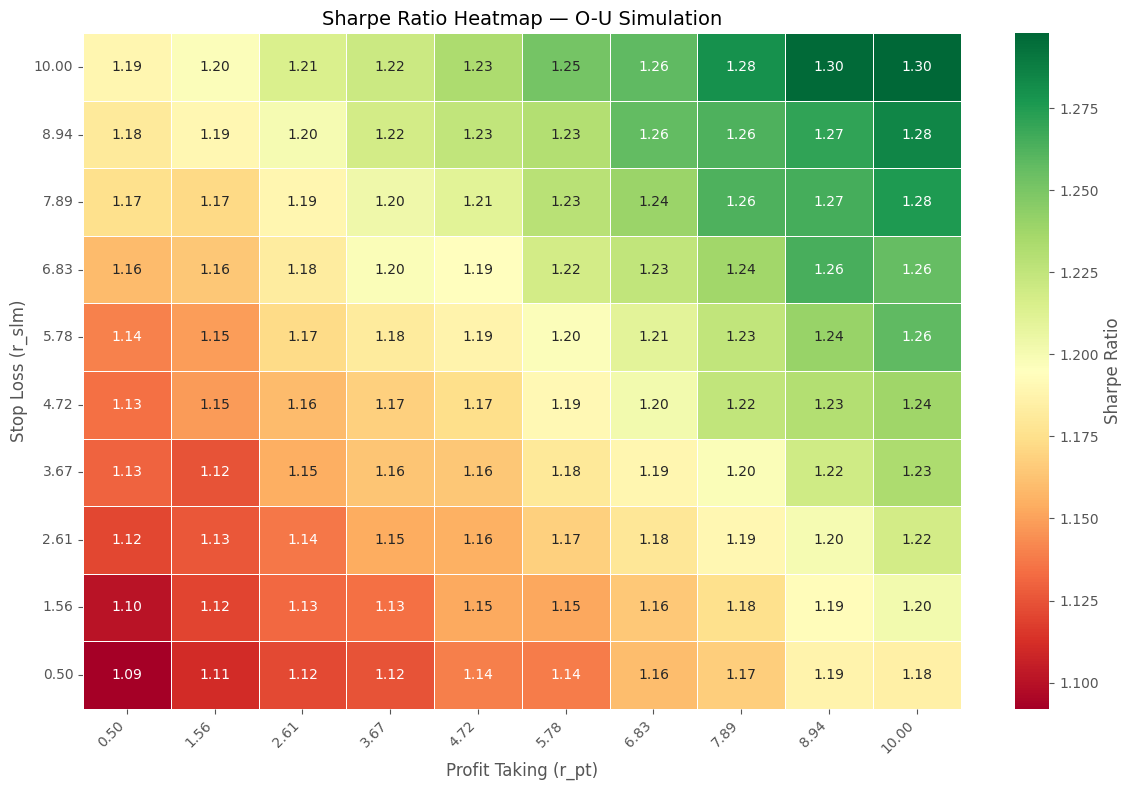

In [21]:
plot_heat_map(eurostoxx_results)

## 4. Repeat exercise 2 after splitting the time series into two parts:

In [22]:
# We simply split the dollar_bars by half
bar_length = len(dollar_bars)
first_time_interval = dollar_bars[:bar_length//2]
second_time_interval = dollar_bars[bar_length//2:]

### a. The first time series ends on 3/15/2009.

=== O-U Process Parameters ===
  Long-run mean    θ  : 97.5802
  Mean-rev. speed  κ  : 0.000012  (per bar)
  Diffusion coeff  σ  : 0.0893
  Half-life            : 55629.0  bars
  β (AR coeff)         : -0.000012  (negative ⟹ mean-reverting)
  R²                   : 0.0000
  p-value (β)          : 2.1037e-02


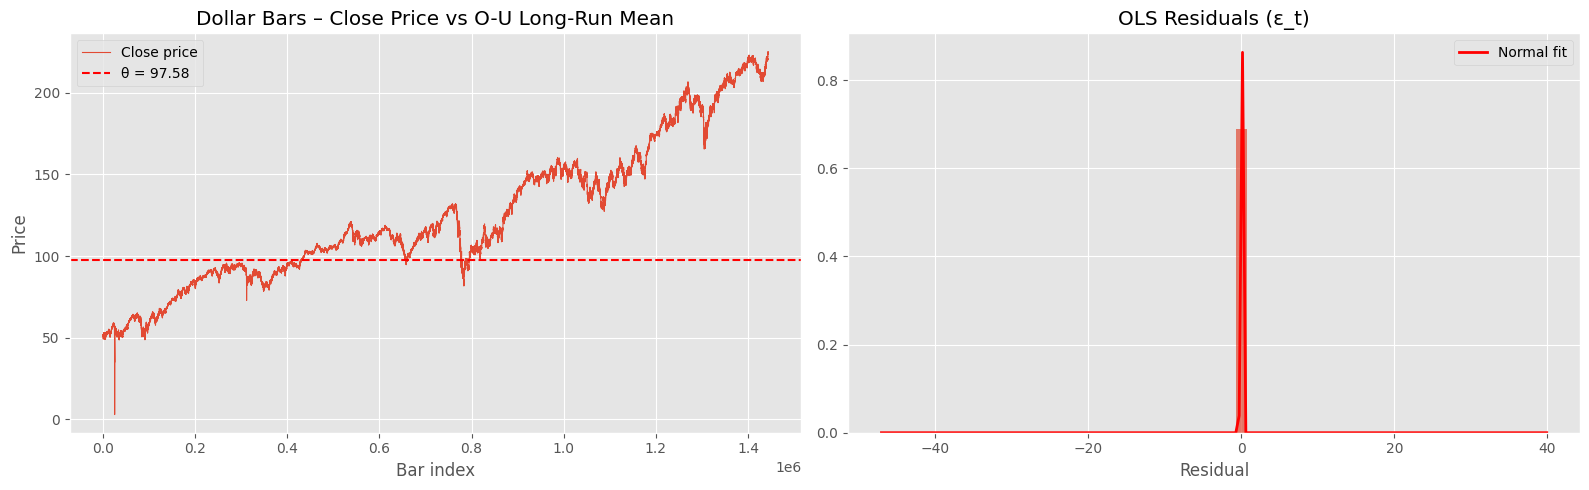

In [ ]:
first_dollar_bars_ou_params = fit_ou_process(first_time_interval["price"])

explain_and_plot_ou_params(first_dollar_bars_ou_params, first_time_interval)

In [27]:
first_dollar_bars_ou_params["phi"] = 1 + first_dollar_bars_ou_params["beta"]
first_dollar_bars_ou_params["forecast"] = -first_dollar_bars_ou_params["alpha"] / first_dollar_bars_ou_params["beta"]

first_results = simulate_ou_process(first_dollar_bars_ou_params, r_pt=profit_targets, r_slm=stop_loss_multipliers)

first_results

0.5 0.5 0.04694166058082397 0.5516253016217408 0.08509700414904589
0.5 1.5555555555555556 0.3661767881996389 0.6080253042558442 0.6022393897698037
0.5 2.611111111111111 0.5420372489187688 0.18627810880009896 2.909827957832911
0.5 3.666666666666667 0.5523748762924391 0.04820832739394486 11.458080090159266
0.5 4.722222222222222 0.5522017374144681 0.04493467788104094 12.288988448439635
0.5 5.777777777777778 0.5524260108973028 0.045010809275705485 12.273185481147834
0.5 6.833333333333334 0.552790741004018 0.04498536114930118 12.28823614796311
0.5 7.888888888888889 0.552370980820705 0.044953806629264674 12.28752406611801
0.5 8.944444444444445 0.5522257504088456 0.04501753743223775 12.266902676319834
0.5 10.0 0.5523767632933846 0.04448688181667435 12.416621276574737
1.5555555555555556 0.5 -0.22812144160323825 0.7719147196134765 -0.2955267412408799
1.5555555555555556 1.5555555555555556 0.37662325376272976 1.5627232673506295 0.24100444501683257
1.5555555555555556 2.611111111111111 1.5308437704

[(np.float64(0.5),
  np.float64(0.5),
  np.float64(0.04694166058082397),
  np.float64(0.5516253016217408),
  np.float64(0.08509700414904589)),
 (np.float64(0.5),
  np.float64(1.5555555555555556),
  np.float64(0.3661767881996389),
  np.float64(0.6080253042558442),
  np.float64(0.6022393897698037)),
 (np.float64(0.5),
  np.float64(2.611111111111111),
  np.float64(0.5420372489187688),
  np.float64(0.18627810880009896),
  np.float64(2.909827957832911)),
 (np.float64(0.5),
  np.float64(3.666666666666667),
  np.float64(0.5523748762924391),
  np.float64(0.04820832739394486),
  np.float64(11.458080090159266)),
 (np.float64(0.5),
  np.float64(4.722222222222222),
  np.float64(0.5522017374144681),
  np.float64(0.04493467788104094),
  np.float64(12.288988448439635)),
 (np.float64(0.5),
  np.float64(5.777777777777778),
  np.float64(0.5524260108973028),
  np.float64(0.045010809275705485),
  np.float64(12.273185481147834)),
 (np.float64(0.5),
  np.float64(6.833333333333334),
  np.float64(0.5527907410

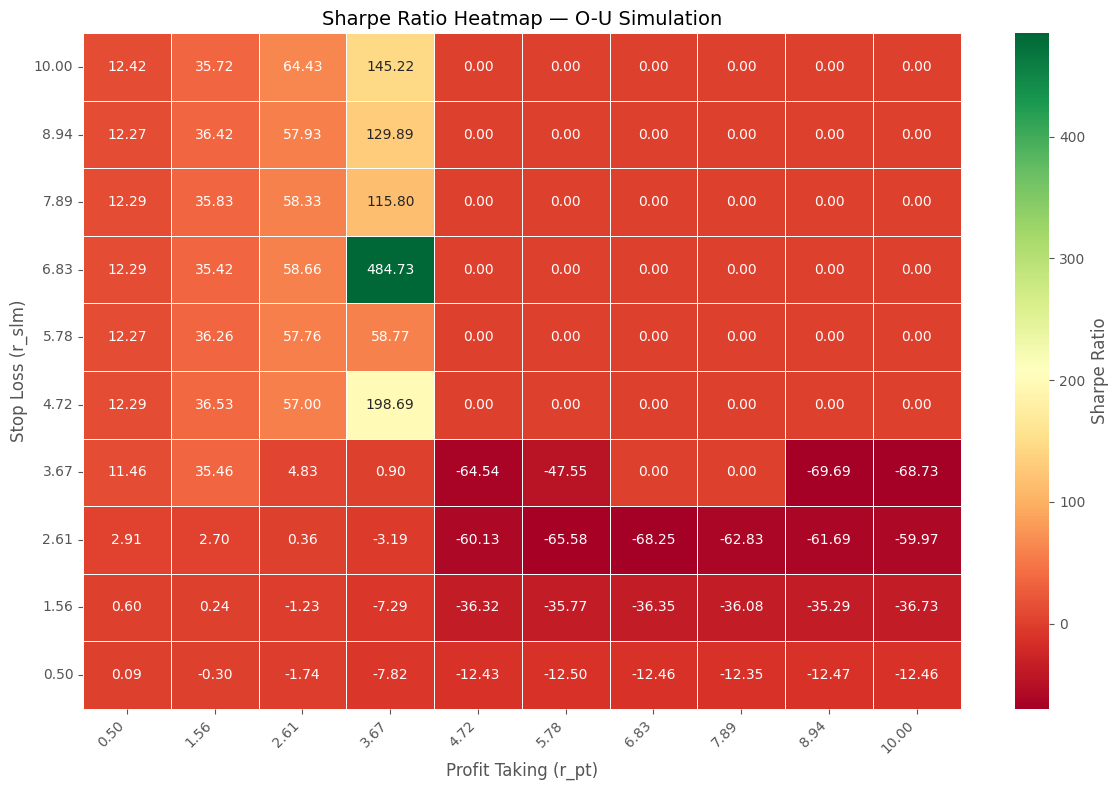

In [30]:
plot_heat_map(first_results)

### b. The second time series starts on 3/16/2009.

=== O-U Process Parameters ===
  Long-run mean    θ  : 264.6819
  Mean-rev. speed  κ  : 0.000001  (per bar)
  Diffusion coeff  σ  : 0.0804
  Half-life            : 484332.9  bars
  β (AR coeff)         : -0.000001  (negative ⟹ mean-reverting)
  R²                   : 0.0000
  p-value (β)          : 6.0561e-01


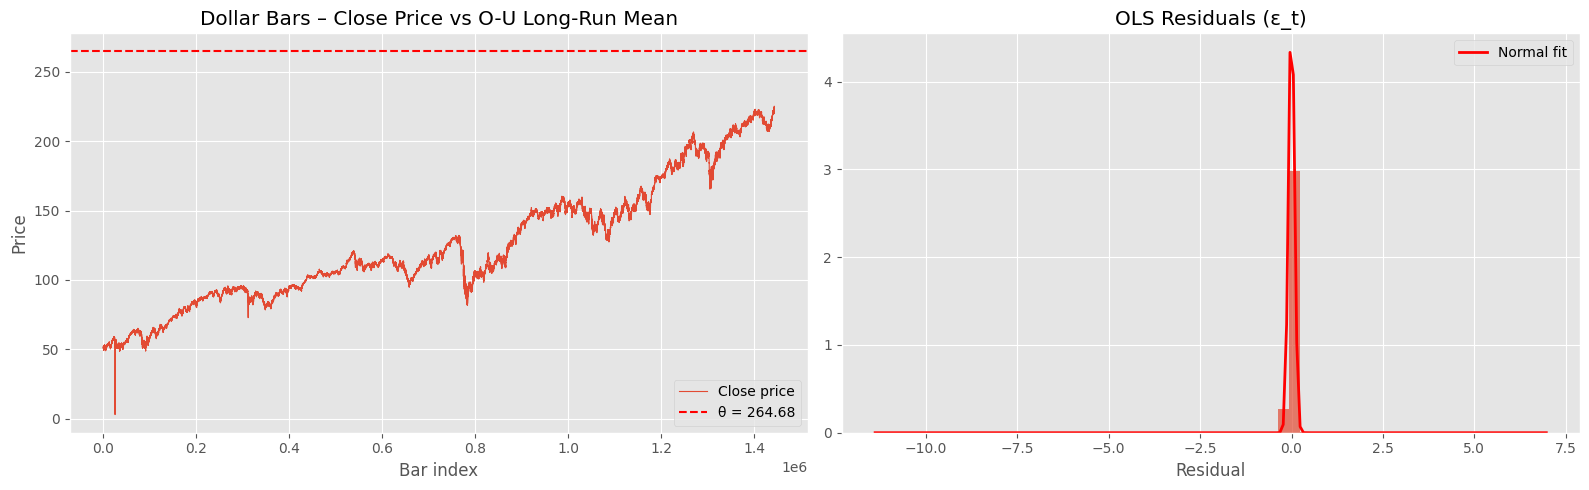

In [ ]:
second_dollar_bars_ou_params = fit_ou_process(second_time_interval["price"])

explain_and_plot_ou_params(second_dollar_bars_ou_params, second_time_interval)

In [29]:
second_dollar_bars_ou_params["phi"] = 1 + second_dollar_bars_ou_params["beta"]
second_dollar_bars_ou_params["forecast"] = -second_dollar_bars_ou_params["alpha"] / second_dollar_bars_ou_params["beta"]

second_results = simulate_ou_process(second_dollar_bars_ou_params, r_pt=profit_targets, r_slm=stop_loss_multipliers)

second_results

0.5 0.5 0.015098929818817613 0.5480778356176693 0.02754887871318773
0.5 1.5555555555555556 0.3849485076675139 0.5687363699494274 0.676848761583058
0.5 2.611111111111111 0.5417442363675331 0.13659739196579632 3.965992531564473
0.5 3.666666666666667 0.546855073605386 0.04015656093140482 13.618075376014403
0.5 4.722222222222222 0.5468634856184162 0.04009800127035444 13.638173183029139
0.5 5.777777777777778 0.5466552805711633 0.040049701752348406 13.649422009468745
0.5 6.833333333333334 0.5468673266842394 0.04009935424415563 13.637808812443502
0.5 7.888888888888889 0.5470360710124417 0.04032732960648823 13.564896965665426
0.5 8.944444444444445 0.5469766286491368 0.04018671017848737 13.61088345425057
0.5 10.0 0.5472713684084497 0.0404773644909109 13.520429882023032
1.5555555555555556 0.5 -0.3392943310852324 0.6361379353658679 -0.5333659765001924
1.5555555555555556 1.5555555555555556 0.13992597091995806 1.5970121634421202 0.08761734827264472
1.5555555555555556 2.611111111111111 1.53602526818

[(np.float64(0.5),
  np.float64(0.5),
  np.float64(0.015098929818817613),
  np.float64(0.5480778356176693),
  np.float64(0.02754887871318773)),
 (np.float64(0.5),
  np.float64(1.5555555555555556),
  np.float64(0.3849485076675139),
  np.float64(0.5687363699494274),
  np.float64(0.676848761583058)),
 (np.float64(0.5),
  np.float64(2.611111111111111),
  np.float64(0.5417442363675331),
  np.float64(0.13659739196579632),
  np.float64(3.965992531564473)),
 (np.float64(0.5),
  np.float64(3.666666666666667),
  np.float64(0.546855073605386),
  np.float64(0.04015656093140482),
  np.float64(13.618075376014403)),
 (np.float64(0.5),
  np.float64(4.722222222222222),
  np.float64(0.5468634856184162),
  np.float64(0.04009800127035444),
  np.float64(13.638173183029139)),
 (np.float64(0.5),
  np.float64(5.777777777777778),
  np.float64(0.5466552805711633),
  np.float64(0.040049701752348406),
  np.float64(13.649422009468745)),
 (np.float64(0.5),
  np.float64(6.833333333333334),
  np.float64(0.54686732668

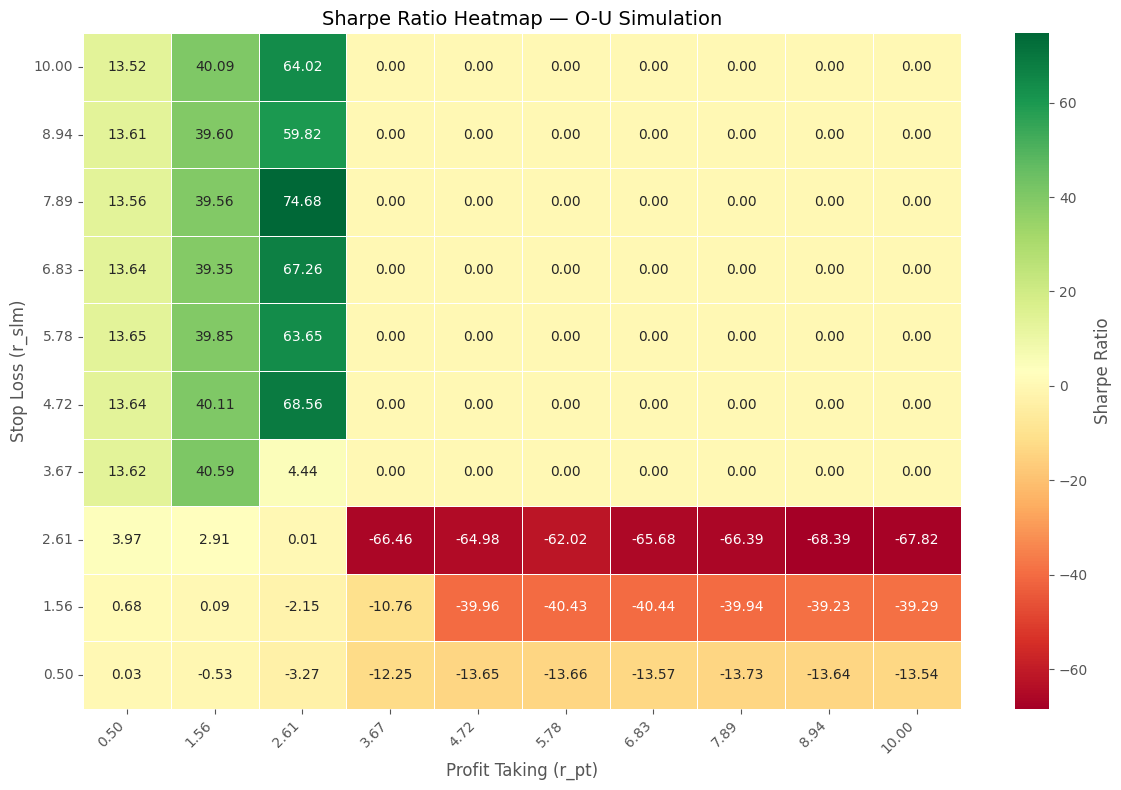

In [31]:
plot_heat_map(second_results)

### c. Are the OTRs significantly different?

In [32]:
first_sharpe_ratios = [res[-1] for res in first_results]
first_max_sr_idx = np.argmax(first_sharpe_ratios)
first_max_sr_values = first_results[first_max_sr_idx]
print(f"The OTR of the first interval is")
print(f"Profit Target: {first_max_sr_values[0]:.2f}")
print(f"Stop Loss Multiplier: {first_max_sr_values[1]:.2f}")
print(f"Sharpe Ratio: {first_max_sr_values[-1]:.2f}")

print()

second_sharpe_ratios = [res[-1] for res in second_results]
second_max_sr_idx = np.argmax(second_sharpe_ratios)
second_max_sr_values = second_results[second_max_sr_idx]
print(f"The OTR of the second interval is")
print(f"Profit Target: {second_max_sr_values[0]:.2f}")
print(f"Stop Loss Multiplier: {second_max_sr_values[1]:.2f}")
print(f"Sharpe Ratio: {second_max_sr_values[-1]:.2f}")

The OTR of the first interval is
Profit Target: 3.67
Stop Loss Multiplier: 6.83
Sharpe Ratio: 484.73

The OTR of the second interval is
Profit Target: 2.61
Stop Loss Multiplier: 7.89
Sharpe Ratio: 74.68


While the OTR did not differ a lot, the sharpe ratio differ significantly. Besides, the larger range of our barrier (profit taking + stop loss) also indicates the need to re-compute the optimal parameters over time.

## 5. How long do you estimate it would take to derive OTRs on the 100 most  liquid futures contracts worldwide? Considering the results from exercise 4, how often do you think you may have to re-calibrate the OTRs? Does it make sense to pre-compute this data?

**Time to derive OTRs for 100 contracts**

Our data spans 2009–2026 (~17 years) and takes ~7 minutes to simulate 10,000 paths. Scaling linearly to a standard 10-year window gives ~4 minutes per contract. With full CPU parallelisation across $N$ cores (via `mpEngine` from Chapter 20), the total wall-clock time is:

$$t_\text{total} \approx \frac{100 \times 4\,\text{min}}{N_\text{cores}}$$

On a modern workstation with, say, 20 cores this comes to ~20 minutes; on a cluster it is negligible. A conservative single-machine estimate is **under 1 hour**.

---

**How often to recalibrate**

Recalibration frequency should be tied to the **half-life** of the fitted O-U process — the natural time-scale over which the process "forgets" its initial condition. If the half-life is $t_{1/2}$ bars, parameters fitted more than a few half-lives ago are stale.

From Exercise 4, the OTR (the location of the Sharpe-maximising barrier pair) is relatively stable across the two sub-periods, but the *magnitude* of the Sharpe ratio changes substantially. This means the process parameters drift over time even if the qualitative shape of the heatmap is preserved.

A principled recalibration policy would be:
- **Rolling window**: re-fit and re-simulate every $t_{1/2}$ bars on a rolling basis.
- **Event-triggered**: re-calibrate upon detecting a structural break (e.g., a CUSUM test or a Chow test on the AR(1) regression residuals), which captures regime changes such as the 2008 crisis or COVID.

A purely calendar-based rule (e.g., weekly) is reasonable as a practical default but is not tied to the dynamics of the process itself.

---

**Does it make sense to pre-compute OTRs?**

Yes — strongly so. The simulation takes minutes per contract, which is far too slow for real-time execution decisions. However, OTRs are a function of the fitted O-U parameters alone, which only change on the recalibration schedule. Pre-computing them as a lookup table decouples the slow offline calibration from the fast online trading logic:

- At recalibration time (e.g., weekly), re-fit the O-U parameters and regenerate the heatmap for each contract.
- At execution time, look up the OTR from the pre-computed table in O(1).

The computational cost is paid once per recalibration period and amortised across all trades that use those parameters until the next refresh.

## 6. Parallelize Snippets 13.1 and 13.2 using the mpEngine module described in  Chapter 20.